In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import f1_score
import spacy
import gensim
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
leetcode_questions_df = pd.read_csv('/content/drive/MyDrive/thesis/leetcode/part2 feature-creation/code_features_extracts.csv')
leetcode_questions_df['num_of_contest'] = leetcode_questions_df.num_of_contest.astype('category')
leetcode_questions_df['question_number'] = leetcode_questions_df.question_number.astype('category')
leetcode_questions_df['finish_time'] = pd.to_datetime(leetcode_questions_df['finish_time'], format='%H:%M:%S').astype(int)
leetcode_questions_df['question_finish_time'] = pd.to_datetime(leetcode_questions_df['question_finish_time'], format='%H:%M:%S').astype(int)

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61834 entries, 0 to 61833
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   username                     61834 non-null  object  
 1   country                      61834 non-null  object  
 2   contest_url                  61834 non-null  object  
 3   num_of_contest               61834 non-null  category
 4   finish_time                  61834 non-null  int64   
 5   is_weekly                    61834 non-null  bool    
 6   rank                         61834 non-null  int64   
 7   score                        61834 non-null  int64   
 8   user_global_rank             61834 non-null  float64 
 9   question_number              61834 non-null  category
 10  question_language            61834 non-null  object  
 11  question_code                61834 non-null  object  
 12  question_finish_time         61834 non-null  int64   
 13  n

In [4]:
leetcode_questions_df.head()

,username,country,contest_url,num_of_contest,finish_time,is_weekly,rank,score,user_global_rank,question_number,...,variables_count,function_count,loop_count,condition_count,single_line_comment_density,multiline_comment_density,function_density,loop_density,condition_density,comment_tokens_density
0,fmota,Brazil,https://leetcode.com/contest/weekly-contest-36...,367,-2208988044000000000,True,2,17,486427.0,1,...,12,1,2,1,0.000000,0.0,0.045455,0.090909,0.045455,0.0
1,nicholask_17,Hong Kong,https://leetcode.com/contest/weekly-contest-36...,367,-2208988018000000000,True,3,17,27684.0,1,...,18,1,2,6,0.000000,0.0,0.032258,0.064516,0.193548,0.0
2,skywalkert,China,https://leetcode.com/contest/weekly-contest-36...,367,-2208987996000000000,True,4,17,16.0,1,...,17,1,1,2,0.000000,0.0,0.037037,0.037037,0.074074,0.0
3,hank55663,Taiwan,https://leetcode.com/contest/weekly-contest-36...,367,-2208987929000000000,True,7,17,6234.0,1,...,12,1,1,5,0.037037,0.0,0.040000,0.040000,0.200000,0.2
4,DimmyT,Kazakhstan,https://leetcode.com/contest/weekly-contest-36...,367,-2208987916000000000,True,8,17,702585.0,1,...,10,1,2,1,0.000000,0.0,0.052632,0.105263,0.052632,0.0


In [5]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_language'] == 'C++']

In [6]:
leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39431 entries, 0 to 61831
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   username                     39431 non-null  object  
 1   country                      39431 non-null  object  
 2   contest_url                  39431 non-null  object  
 3   num_of_contest               39431 non-null  category
 4   finish_time                  39431 non-null  int64   
 5   is_weekly                    39431 non-null  bool    
 6   rank                         39431 non-null  int64   
 7   score                        39431 non-null  int64   
 8   user_global_rank             39431 non-null  float64 
 9   question_number              39431 non-null  category
 10  question_language            39431 non-null  object  
 11  question_code                39431 non-null  object  
 12  question_finish_time         39431 non-null  int64   
 13  number

In [7]:
leetcode_questions_df.country.value_counts()

country
India            25460
United States     3850
Taiwan            2264
China             1351
Canada             820
                 ...  
Greece               3
Nigeria              3
Chad                 3
Ethiopia             1
Spain                1
Name: count, Length: 74, dtype: int64

<Axes: ylabel='Frequency'>

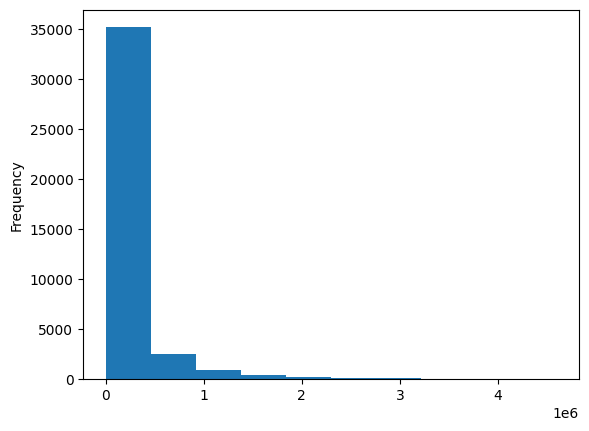

In [8]:
leetcode_questions_df['user_global_rank'].plot.hist()

In [9]:
leetcode_questions_df['user_global_rank'].max(), leetcode_questions_df['user_global_rank'].mean(), leetcode_questions_df['user_global_rank'].median()

(4598201.0, 175567.15924019172, 41317.0)

<Axes: ylabel='Frequency'>

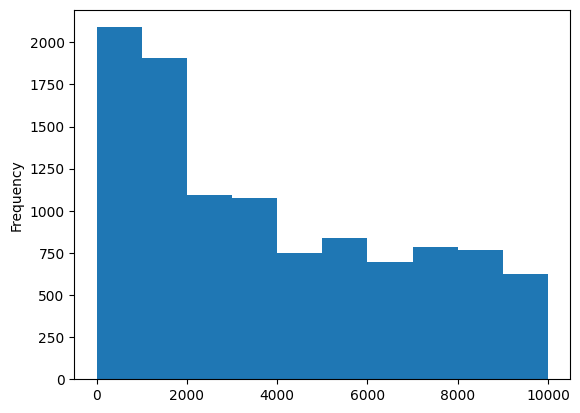

In [10]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['user_global_rank'] < 10000]

leetcode_questions_df['user_global_rank'].plot.hist()

In [11]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df.groupby('country')['country'].transform('size') > 100]
leetcode_questions_df['country'] = leetcode_questions_df.country.astype('category')

<ipython-input-11-22d56a376d39>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  leetcode_questions_df['country'] = leetcode_questions_df.country.astype('category')


array([<Axes: title={'center': 'China'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Hong Kong'}, ylabel='Frequency'>,
       <Axes: title={'center': 'India'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Japan'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Taiwan'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Ukraine'}, ylabel='Frequency'>,
       <Axes: title={'center': 'United States'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Vietnam'}, ylabel='Frequency'>],
      dtype=object)

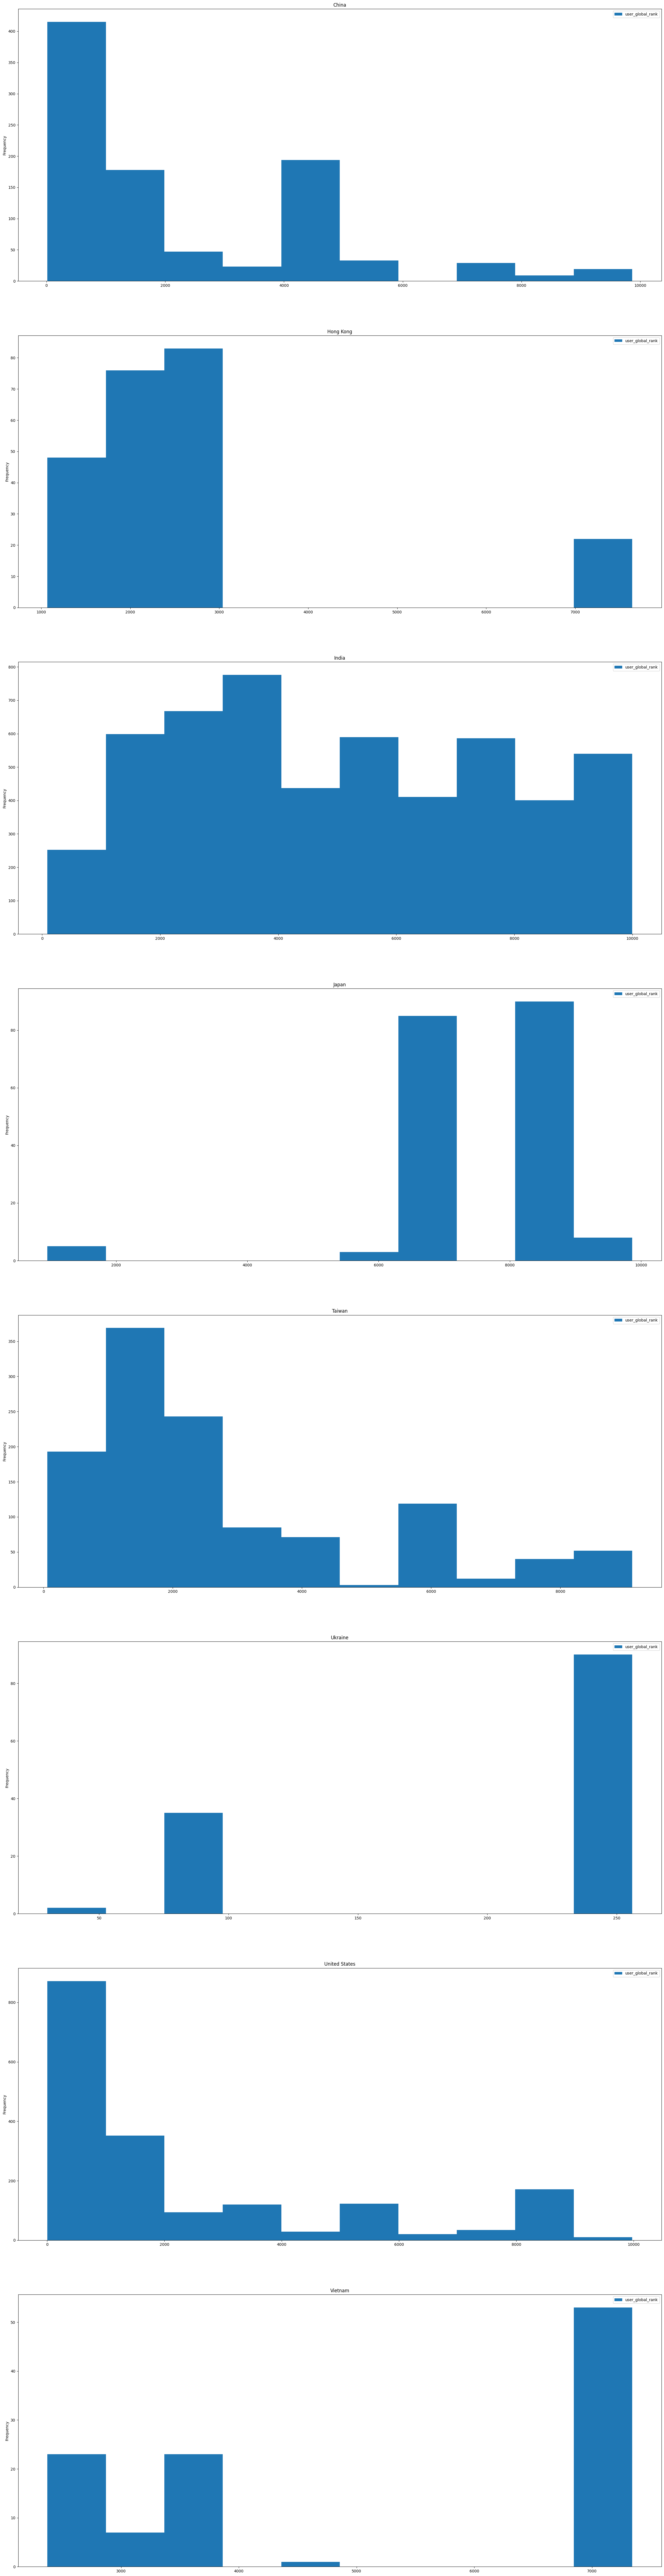

In [12]:
leetcode_questions_df.plot.hist(column=["user_global_rank"], by="country", figsize=(30, 120))

In [13]:
X=leetcode_questions_df.drop('country',axis=1)
Y=leetcode_questions_df['country']

In [14]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9873 entries, 2 to 61829
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   username                     9873 non-null   object  
 1   contest_url                  9873 non-null   object  
 2   num_of_contest               9873 non-null   category
 3   finish_time                  9873 non-null   int64   
 4   is_weekly                    9873 non-null   bool    
 5   rank                         9873 non-null   int64   
 6   score                        9873 non-null   int64   
 7   user_global_rank             9873 non-null   float64 
 8   question_number              9873 non-null   category
 9   question_language            9873 non-null   object  
 10  question_code                9873 non-null   object  
 11  question_finish_time         9873 non-null   int64   
 12  number_of_lines              9873 non-null   int64   
 13  names_s

# Non text features

In [15]:
X_nontext=X[['user_global_rank', 'num_of_contest',
            'finish_time', 'is_weekly', 'score', 'username',
            'question_number', 'question_finish_time', 'number_of_lines',
            'token_count', 'variables_count', 'function_count', 'loop_count',
            'condition_count', 'single_line_comment_density',
            'multiline_comment_density', 'function_density', 'loop_density',
            'condition_density', 'comment_tokens_density']]
X_nontext.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9873 entries, 2 to 61829
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   user_global_rank             9873 non-null   float64 
 1   num_of_contest               9873 non-null   category
 2   finish_time                  9873 non-null   int64   
 3   is_weekly                    9873 non-null   bool    
 4   score                        9873 non-null   int64   
 5   username                     9873 non-null   object  
 6   question_number              9873 non-null   category
 7   question_finish_time         9873 non-null   int64   
 8   number_of_lines              9873 non-null   int64   
 9   token_count                  9873 non-null   int64   
 10  variables_count              9873 non-null   int64   
 11  function_count               9873 non-null   int64   
 12  loop_count                   9873 non-null   int64   
 13  conditi

In [16]:
X_train_nontext = X_nontext.iloc[:0]
X_test_nontext = X_nontext.iloc[:0]
y_train = pd.Series()
y_test = pd.Series()

unique_countries = Y.unique()

for country in unique_countries:
    country_data = X_nontext[Y == country]

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

    groups = country_data['username'].values

    for train_indices, test_indices in splitter.split(X.loc[country_data.index], Y.loc[country_data.index], groups=groups):
        X_train_nontext = X_train_nontext._append(country_data.iloc[train_indices], ignore_index = True)
        X_test_nontext = X_test_nontext._append(country_data.iloc[test_indices], ignore_index = True)
        y_train = pd.concat([y_train, Y.loc[country_data.index[train_indices]]], ignore_index=True)
        y_test = pd.concat([y_test, Y.loc[country_data.index[test_indices]]], ignore_index=True)

X_train_nontext.drop('username', axis=1, inplace=True)
X_test_nontext.drop('username', axis=1, inplace=True)

In [17]:
#handle categorical columns

categorical = X_train_nontext.dtypes == 'category'

preprocess = make_column_transformer(
    (StandardScaler(), ~categorical),
    (OneHotEncoder(drop='first',handle_unknown='ignore'), categorical))

baseline_model = Pipeline([('encoder_scaler',preprocess),
                           ('svc',SVC())])

In [18]:
param_grid = [{'svc__C': np.logspace(0,3,4)}]
svc_cv= GridSearchCV(baseline_model, param_grid,cv=5,return_train_score=True)
svc_cv.fit(X_train_nontext, y_train)
print("nontext grid SVC train score ", svc_cv.score(X_train_nontext, y_train))
print("nontext grid SVC test score ", svc_cv.score(X_test_nontext, y_test))
print("nontext SVC train f1 score ", f1_score(y_train, svc_cv.predict(X_train_nontext), average='weighted'))
print("nontext SVC test f1 score ", f1_score(y_test,svc_cv.predict(X_test_nontext), average='weighted'))
svc_cv.best_params_

nontext grid SVC train score  0.6541547277936963
nontext grid SVC test score  0.5789837538886968
nontext SVC train f1 score  0.5968862491251062
nontext SVC test f1 score  0.5061388523160898


{'svc__C': 1.0}

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


               precision    recall  f1-score   support

        China       0.09      0.02      0.03       283
    Hong Kong       0.00      0.00      0.00        51
        India       0.64      0.92      0.76      1548
        Japan       0.00      0.00      0.00        74
       Taiwan       0.10      0.01      0.03       280
      Ukraine       0.00      0.00      0.00        35
United States       0.53      0.39      0.45       606
      Vietnam       0.00      0.00      0.00        16

     accuracy                           0.58      2893
    macro avg       0.17      0.17      0.16      2893
 weighted avg       0.47      0.58      0.51      2893

f1_score :  0.5061388523160898


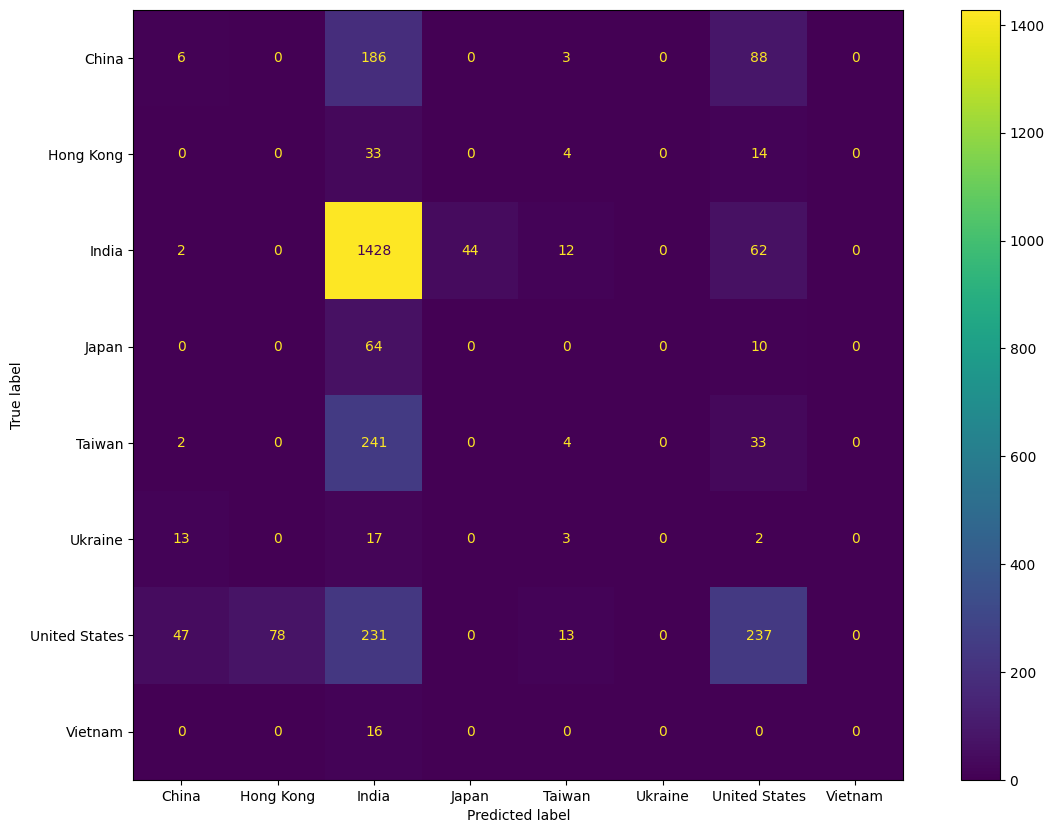

In [19]:
y_pred_test = svc_cv.predict(X_test_nontext)

print(classification_report(y_test, y_pred_test))

print("f1_score : ",f1_score(y_test, y_pred_test, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_test), display_labels=svc_cv.classes_)

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

# simple BOW

In [20]:
X_text=X[['username','question_code']]
X_train_text = X_text.iloc[:0]
X_test_text = X_text.iloc[:0]
y_train = pd.Series()
y_test = pd.Series()

unique_countries = Y.unique()

for country in unique_countries:
    country_data = X_text[Y == country]

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

    groups = country_data['username'].values

    for train_indices, test_indices in splitter.split(X.loc[country_data.index], Y.loc[country_data.index], groups=groups):
        X_train_text = X_train_text._append(country_data.iloc[train_indices], ignore_index = True)
        X_test_text = X_test_text._append(country_data.iloc[test_indices], ignore_index = True)
        y_train = pd.concat([y_train, Y.loc[country_data.index[train_indices]]], ignore_index=True)
        y_test = pd.concat([y_test, Y.loc[country_data.index[test_indices]]], ignore_index=True)

X_train_text = X_train_text.question_code
X_test_text = X_test_text.question_code

In [22]:
custom_token_pattern = r'\b[A-Za-z_]\w*\b'

vect = CountVectorizer(stop_words='english', min_df=10, max_df=0.8, token_pattern=custom_token_pattern)
X_train_simple=vect.fit_transform(X_train_text)
X_test_simple=vect.transform(X_test_text)
print(vect.get_feature_names_out())

['_' '__builtin_clz' '__builtin_popcount' '__builtin_popcountll'
 '__db_level' '__function__' '__gcd' '__gnu_pbds' '__int128' '__line__'
 '__linux__' '__typeof' '__va_args__' '_c' '_default' '_f1' '_f2' '_f3'
 '_get' '_id' '_if' '_in' '_init' '_int' '_len' '_len2' '_ll' '_madd'
 '_max' '_min' '_mm' '_n' '_oo' '_p' '_rep' '_sort' '_swap' '_this' '_un'
 '_vvi' '_vvl' '_vvvi' '_x' '_xor' '_y' '_y_default' 'a1' 'a2' 'aa'
 'aaacaaaa' 'abs' 'access_times' 'accumulate' 'acos' 'add' 'adj' 'ai'
 'algorithm' 'algorithms' 'amax' 'amin' 'ans' 'ans1' 'ans2' 'answer'
 'append' 'apple' 'area' 'areaofmaxdiagonal' 'aresimilar' 'args' 'arr'
 'arr1' 'arr2' 'array' 'assert' 'assign' 'assoc_container' 'author' 'auto'
 'aux' 'avg' 'b' 'b1' 'b2' 'bad' 'base' 'batterypercentages' 'bb'
 'beautifulindices' 'beautifulsubstrings' 'begin' 'bend' 'best' 'bfind'
 'bin1' 'binary' 'binpow' 'bit' 'bitcnt' 'bits' 'bitset' 'bl' 'bool'
 'bottomleft' 'break' 'bs' 'buffer' 'build' 'c' 'c1' 'c2' 'calc'
 'calculate' 'calculat

In [23]:
svc = SVC().fit(X_train_simple, y_train)
print("simple BOW SVC train score ",svc.score(X_train_simple, y_train))
print("simple BOW SVC test score ",svc.score(X_test_simple, y_test))
print("simple BOW SVC train f1 score ", f1_score(y_train, svc.predict(X_train_simple), average='weighted'))
print("simple BOW SVC test f1 score ", f1_score(y_test, svc.predict(X_test_simple), average='weighted'))

simple BOW SVC train score  0.5954154727793697
simple BOW SVC test score  0.5375043207742828
simple BOW SVC train f1 score  0.4884447038792075
simple BOW SVC test f1 score  0.38419959853537755


# n-grams tf-idf

In [24]:
wordnet_lem = WordNetLemmatizer()

X_train_lemma=X_train_text.apply(wordnet_lem.lemmatize)
X_test_lemma=X_test_text.apply(wordnet_lem.lemmatize)

In [25]:
tfidf_pipeline = make_pipeline(CountVectorizer(stop_words='english',ngram_range=(2,10),min_df=10, max_df=0.8),
                      Normalizer(),
                      TfidfTransformer(),
                      SVC(random_state=0),memory="cache_folder")

In [26]:
param_grid = [{
    'countvectorizer__ngram_range':[(2, 5), (5,9)],
    'svc__C':np.logspace(-2,2,5)}]

svc_cv= GridSearchCV(tfidf_pipeline, param_grid,cv=5,return_train_score=True)

svc_cv.fit(X_train_lemma, y_train)

print("n-grams grid SVC train score ",svc_cv.score(X_train_lemma, y_train))
print("n-grams grid SVC test score ",svc_cv.score(X_test_lemma, y_test))
print("n-grams SVC train f1 score ", f1_score(y_train, svc_cv.predict(X_train_lemma), average='weighted'))
print("n-grams SVC test f1 score ", f1_score(y_test, svc_cv.predict(X_test_lemma), average='weighted'))
svc_cv.best_params_

n-grams grid SVC train score  0.9855300859598853
n-grams grid SVC test score  0.5247148288973384
n-grams SVC train f1 score  0.985490833160691
n-grams SVC test f1 score  0.46155166127054803


{'countvectorizer__ngram_range': (2, 5), 'svc__C': 10.0}

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


               precision    recall  f1-score   support

        China       0.27      0.08      0.13       283
    Hong Kong       0.00      0.00      0.00        51
        India       0.60      0.85      0.71      1548
        Japan       0.00      0.00      0.00        74
       Taiwan       0.25      0.15      0.19       280
      Ukraine       0.00      0.00      0.00        35
United States       0.31      0.21      0.25       606
      Vietnam       0.00      0.00      0.00        16

     accuracy                           0.52      2893
    macro avg       0.18      0.16      0.16      2893
 weighted avg       0.44      0.52      0.46      2893

f1_score :  0.46155166127054803


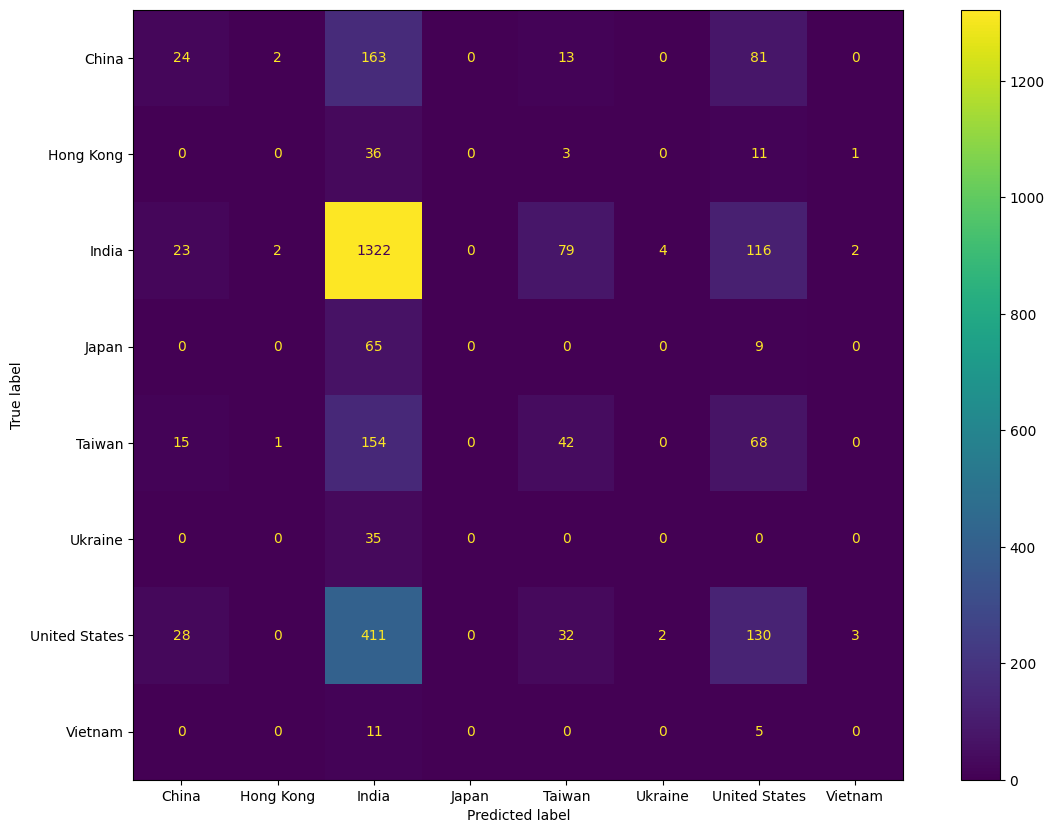

In [27]:
y_pred_test = svc_cv.predict(X_test_lemma)

print(classification_report(y_test, y_pred_test))

print("f1_score : ",f1_score(y_test, y_pred_test, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_test), display_labels=svc_cv.classes_)

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

In [28]:
results = pd.DataFrame(svc_cv.cv_results_)
results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_countvectorizer__ngram_range,param_svc__C,params,split0_test_score,split1_test_score,split2_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,29.747476,2.173118,5.930806,0.927787,"(2, 5)",0.01,"{'countvectorizer__ngram_range': (2, 5), 'svc_...",0.531519,0.531519,0.532235,...,0.531805,0.000351,7,0.531877,0.531877,0.531698,0.531698,0.531877,0.531805,0.000088
1,29.351408,1.875784,5.033297,0.519076,"(2, 5)",0.1,"{'countvectorizer__ngram_range': (2, 5), 'svc_...",0.560888,0.568768,0.574499,...,0.569771,0.004892,4,0.571991,0.570021,0.568589,0.568768,0.569484,0.569771,0.001223
2,29.296736,2.222314,4.847395,0.610790,"(2, 5)",1.0,"{'countvectorizer__ngram_range': (2, 5), 'svc_...",0.540115,0.629656,0.631805,...,0.611175,0.036765,3,0.843123,0.817156,0.817156,0.801039,0.785817,0.812858,0.019099
3,33.737612,2.425190,4.956736,0.677213,"(2, 5)",10.0,"{'countvectorizer__ngram_range': (2, 5), 'svc_...",0.563754,0.662607,0.655444,...,0.641547,0.043103,1,0.994269,0.986748,0.982450,0.982271,0.980838,0.985315,0.004894
4,34.205040,1.874131,5.529897,0.790216,"(2, 5)",100.0,"{'countvectorizer__ngram_range': (2, 5), 'svc_...",0.563037,0.659742,0.651862,...,0.640115,0.043475,2,0.995523,0.988897,0.985673,0.985673,0.984957,0.988145,0.003934
5,22.640078,2.298975,4.914512,0.970688,"(5, 9)",0.01,"{'countvectorizer__ngram_range': (5, 9), 'svc_...",0.531519,0.531519,0.532235,...,0.531805,0.000351,7,0.531877,0.531877,0.531698,0.531698,0.531877,0.531805,0.000088
6,16.107711,1.399188,4.173353,0.872568,"(5, 9)",0.1,"{'countvectorizer__ngram_range': (5, 9), 'svc_...",0.548711,0.568768,0.574499,...,0.567335,0.009536,5,0.573603,0.570021,0.568589,0.568768,0.569484,0.570093,0.001828
7,14.841470,0.839838,3.987363,0.915063,"(5, 9)",1.0,"{'countvectorizer__ngram_range': (5, 9), 'svc_...",0.489255,0.552292,0.585244,...,0.552149,0.034073,6,0.668517,0.654370,0.647923,0.653653,0.629477,0.650788,0.012631
8,15.879017,0.640341,3.275935,0.456032,"(5, 9)",10.0,"{'countvectorizer__ngram_range': (5, 9), 'svc_...",0.472063,0.528653,0.545845,...,0.530229,0.037068,9,0.864076,0.845809,0.850287,0.833632,0.814291,0.841619,0.016779
9,16.767246,0.743771,3.608396,0.544729,"(5, 9)",100.0,"{'countvectorizer__ngram_range': (5, 9), 'svc_...",0.466332,0.522923,0.540831,...,0.522636,0.036010,10,0.894878,0.877328,0.877507,0.859420,0.845809,0.870989,0.016860


#Pretrained Work Vectors

In [29]:
%%python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.7/587.7 MB 2.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [30]:
nlp = spacy.load("en_core_web_lg", disable=["tagger", "parser", "ner","lemmatizer"])
docs_train = [nlp(d).vector for d in X_train_text]
docs_test = [nlp(d).vector for d in X_test_text]

In [31]:
X_train_w2v = np.vstack(docs_train)
X_test_w2v = np.vstack(docs_test)
X_train_w2v.shape, X_test_w2v.shape

((6980, 300), (2893, 300))

In [32]:
param_grid = [{'C':np.logspace(-2,2,10)}]
svc_cv= GridSearchCV(SVC(random_state=0), param_grid,cv=5)
svc_cv.fit(X_train_w2v, y_train)
print("spacy grid SVC train score ",svc_cv.score(X_train_w2v, y_train))
print("spacy grid SVC test score ",svc_cv.score(X_test_w2v, y_test))
print("spacy SVC train f1 score ", f1_score(y_train, svc_cv.predict(X_train_w2v), average='weighted'))
print("spacy SVC test f1 score ", f1_score(y_test, svc_cv.predict(X_test_w2v), average='weighted'))
svc_cv.best_params_

spacy grid SVC train score  0.776647564469914
spacy grid SVC test score  0.5343933632907016
spacy SVC train f1 score  0.7646363051803903
spacy SVC test f1 score  0.4843420152347548


{'C': 100.0}

               precision    recall  f1-score   support

        China       0.27      0.12      0.16       283
    Hong Kong       0.00      0.00      0.00        51
        India       0.66      0.85      0.74      1548
        Japan       0.00      0.00      0.00        74
       Taiwan       0.14      0.06      0.08       280
      Ukraine       0.00      0.00      0.00        35
United States       0.32      0.30      0.31       606
      Vietnam       0.00      0.00      0.00        16

     accuracy                           0.53      2893
    macro avg       0.17      0.17      0.16      2893
 weighted avg       0.46      0.53      0.48      2893

f1_score :  0.4843420152347548


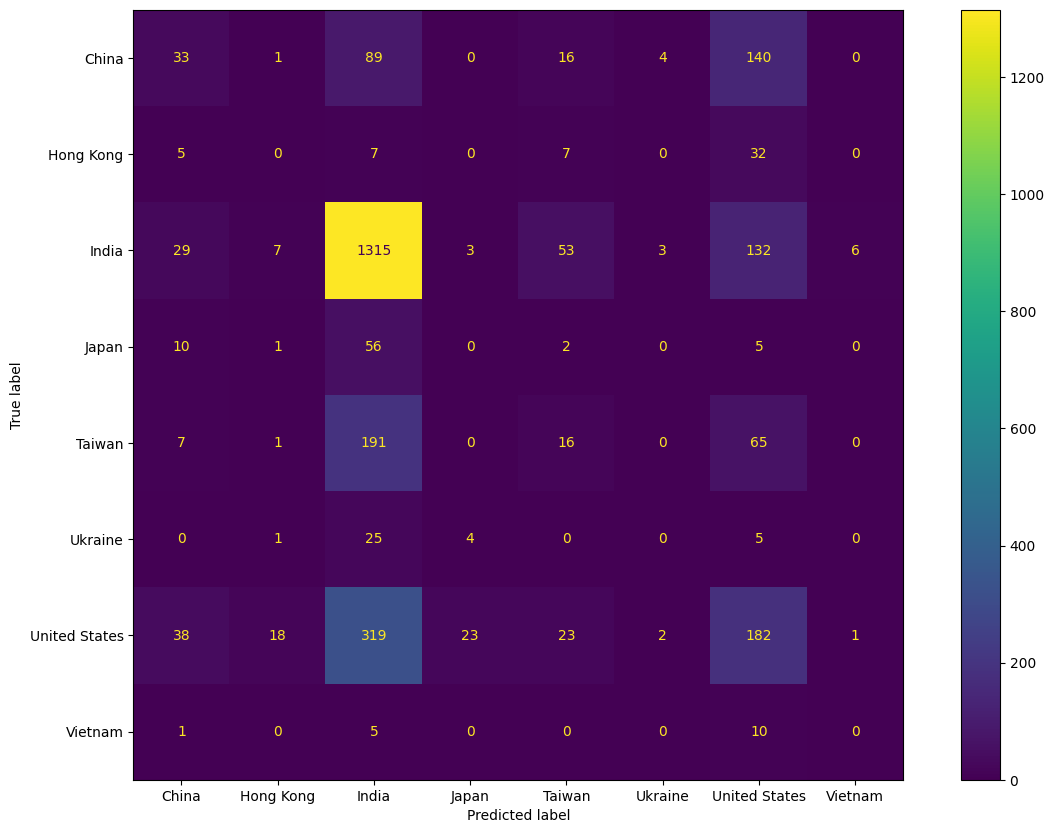

In [33]:
y_pred_test = svc_cv.predict(X_test_w2v)

print(classification_report(y_test, y_pred_test))

print("f1_score : ",f1_score(y_test, y_pred_test, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_test), display_labels=svc_cv.classes_)

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

In [34]:
def read_corpus(text, tokens_only=False):
    for i, line in enumerate(text):
        tokens = gensim.utils.simple_preprocess(line)
        if tokens_only:
            yield tokens
        else:
        # For training data, add tags
            yield gensim.models.doc2vec.TaggedDocument(tokens, [i])

train_corpus = list(read_corpus(X_train_text))
test_corpus = list(read_corpus(X_test_text, tokens_only=True))

In [35]:
model = gensim.models.doc2vec.Doc2Vec(vector_size=50, min_count=2)
model.build_vocab(train_corpus)
model.train(train_corpus, total_examples=model.corpus_count, epochs=55)

In [36]:
vectors = [model.infer_vector(train_corpus[doc_id].words) for doc_id in range(len(train_corpus))]
X_train_doc2vec = np.vstack(vectors)

test_vectors = [model.infer_vector(test_corpus[doc_id]) for doc_id in range(len(test_corpus))]
X_test_doc2vec = np.vstack(test_vectors)

X_train_doc2vec.shape , X_test_doc2vec.shape

((6980, 50), (2893, 50))

In [37]:
param_grid = [{'C':np.logspace(-2,2,5)}]
svc_cv= GridSearchCV(SVC(random_state=0), param_grid,cv=5)
svc_cv.fit(X_train_doc2vec, y_train)
print("gensim grid SVC train score ",svc_cv.score(X_train_doc2vec, y_train))
print("gensim grid SVC test score ",svc_cv.score(X_test_doc2vec, y_test))
print("gensim SVC train f1 score ", f1_score(y_train, svc_cv.predict(X_train_doc2vec), average='weighted'))
print("gensim SVC test f1 score ", f1_score(y_test, svc_cv.predict(X_test_doc2vec), average='weighted'))
svc_cv.best_params_

gensim grid SVC train score  0.863323782234957
gensim grid SVC test score  0.5115796750777739
gensim SVC train f1 score  0.8584123819757935
gensim SVC test f1 score  0.43433490585839757


{'C': 10.0}

# Combine Text and non text features

In [38]:
X_train_combined=pd.concat([X_train_lemma,X_train_nontext],axis=1)

X_test_combined=pd.concat([X_test_lemma,X_test_nontext],axis=1)

X_train_combined.head(5)

,question_code,user_global_rank,num_of_contest,finish_time,is_weekly,score,question_number,question_finish_time,number_of_lines,token_count,variables_count,function_count,loop_count,condition_count,single_line_comment_density,multiline_comment_density,function_density,loop_density,condition_density,comment_tokens_density
0,class Solution {\npublic:\n vector<int> fin...,16.0,367,-2208987996000000000,True,17,1,-2208988524000000000,17,27,17,1,1,2,0.000000,0.0,0.037037,0.037037,0.074074,0.000000
1,class Solution {\npublic:\n vector<int> fin...,154.0,367,-2208987370000000000,True,17,1,-2208988686000000000,15,19,10,1,2,1,0.000000,0.0,0.052632,0.105263,0.052632,0.000000
2,class Solution {\npublic:\n vector<int> fin...,1032.0,367,-2208987318000000000,True,17,1,-2208988375000000000,19,21,11,1,1,5,0.000000,0.0,0.047619,0.047619,0.238095,0.000000
3,class Solution {\npublic:\n vector<int> fin...,368.0,367,-2208985507000000000,True,17,1,-2208988553000000000,16,19,10,1,2,2,0.000000,0.0,0.052632,0.105263,0.105263,0.000000
4,typedef vector<TreeNode*> vt;\ntypedef TreeNod...,4611.0,367,-2208983320000000000,True,17,1,-2208988634000000000,269,247,185,124,11,39,0.011194,0.0,0.502024,0.044534,0.157895,0.040486


In [39]:
X_train_combined.dtypes

question_code                    object
user_global_rank                float64
num_of_contest                 category
finish_time                       int64
is_weekly                          bool
score                             int64
question_number                category
question_finish_time              int64
number_of_lines                   int64
token_count                       int64
variables_count                   int64
function_count                    int64
loop_count                        int64
condition_count                   int64
single_line_comment_density     float64
multiline_comment_density       float64
function_density                float64
loop_density                    float64
condition_density               float64
comment_tokens_density          float64
dtype: object

In [40]:
categorical = X_train_combined.dtypes == 'category'

tfidf = make_pipeline(CountVectorizer(stop_words='english', ngram_range=(2,10), min_df=10, max_df=0.8 ,token_pattern=custom_token_pattern),
                      Normalizer(),
                      TfidfTransformer(),memory="cache_folder")

make_column_transformer(
    (StandardScaler(), ~categorical),
    (OneHotEncoder(drop='first',handle_unknown='ignore'), categorical))

preprocessor_combined = make_column_transformer((tfidf, 'question_code'),
                                                (StandardScaler(), ~categorical & (X_train_combined.dtypes != object)),
                                                (OneHotEncoder(drop='first',handle_unknown='ignore'), categorical))

combine_model = Pipeline([('transformer',preprocessor_combined),
                           ('svc',SVC(random_state=0))])

In [41]:
scores = cross_val_score(combine_model, X_train_combined, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

baseline model score:  0.6243553008595988


In [42]:
param_grid = [{
    'transformer__pipeline__countvectorizer__ngram_range':[(2, 5), (3, 6)],
    'svc__C':np.logspace(-2,2,5)}]

svc_cv= GridSearchCV(combine_model, param_grid,cv=5,return_train_score=True)

svc_cv.fit(X_train_combined, y_train)

print("combined grid SVC train score ",svc_cv.score(X_train_combined, y_train))
print("combined grid SVC test score ",svc_cv.score(X_test_combined, y_test))
print("combined SVC train f1 score ", f1_score(y_train, svc_cv.predict(X_train_combined), average='weighted'))
print("combined SVC test f1 score ", f1_score(y_test, svc_cv.predict(X_test_combined), average='weighted'))
svc_cv.best_params_

combined grid SVC train score  0.9977077363896848
combined grid SVC test score  0.561700656757691
combined SVC train f1 score  0.9977025244008851
combined SVC test f1 score  0.5406345458373257


{'svc__C': 100.0,
 'transformer__pipeline__countvectorizer__ngram_range': (2, 5)}

               precision    recall  f1-score   support

        China       1.00      1.00      1.00       664
    Hong Kong       1.00      1.00      1.00       178
        India       1.00      1.00      1.00      3712
        Japan       1.00      1.00      1.00       117
       Taiwan       1.00      0.99      0.99       907
      Ukraine       1.00      1.00      1.00        92
United States       1.00      1.00      1.00      1219
      Vietnam       1.00      1.00      1.00        91

     accuracy                           1.00      6980
    macro avg       1.00      1.00      1.00      6980
 weighted avg       1.00      1.00      1.00      6980

f1_score :  0.9977025244008851


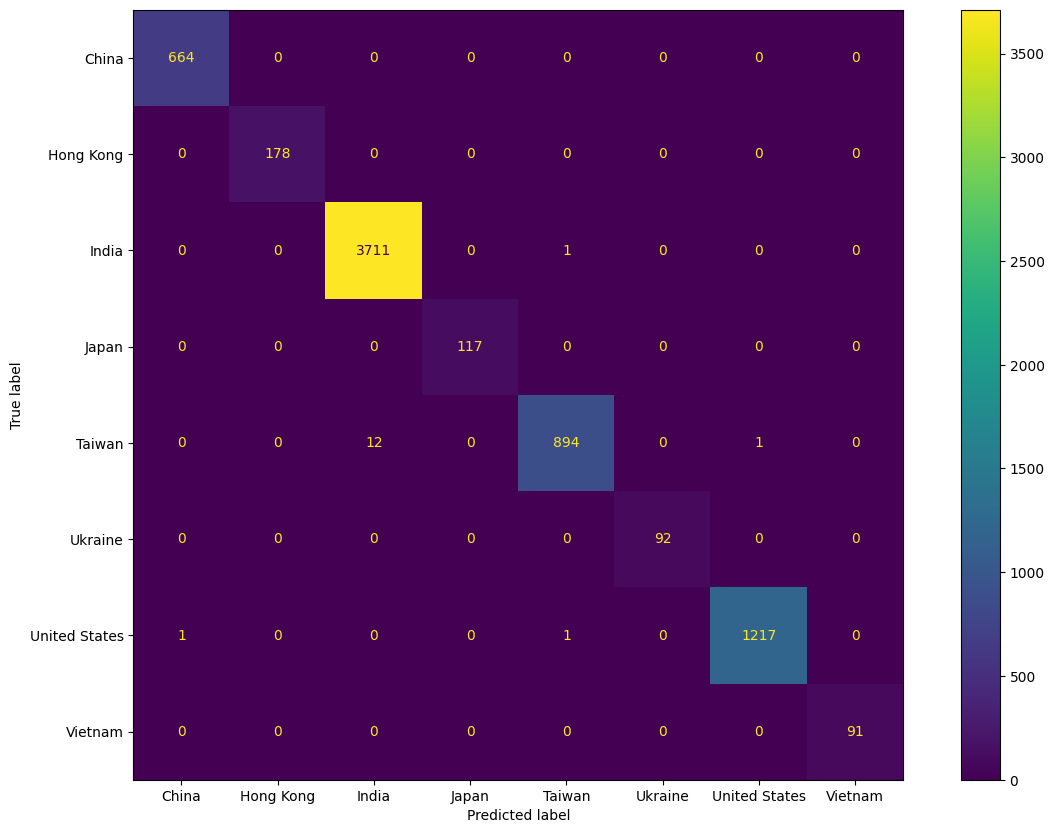

In [43]:
y_pred_train = svc_cv.predict(X_train_combined)

print(classification_report(y_train, y_pred_train))

print("f1_score : ",f1_score(y_train, y_pred_train, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_train, y_pred_train), display_labels=svc_cv.classes_)

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

               precision    recall  f1-score   support

        China       0.16      0.14      0.15       283
    Hong Kong       0.00      0.00      0.00        51
        India       0.72      0.82      0.77      1548
        Japan       0.00      0.00      0.00        74
       Taiwan       0.26      0.22      0.24       280
      Ukraine       0.26      0.23      0.24        35
United States       0.45      0.42      0.43       606
      Vietnam       0.00      0.00      0.00        16

     accuracy                           0.56      2893
    macro avg       0.23      0.23      0.23      2893
 weighted avg       0.52      0.56      0.54      2893

f1_score :  0.5406345458373257


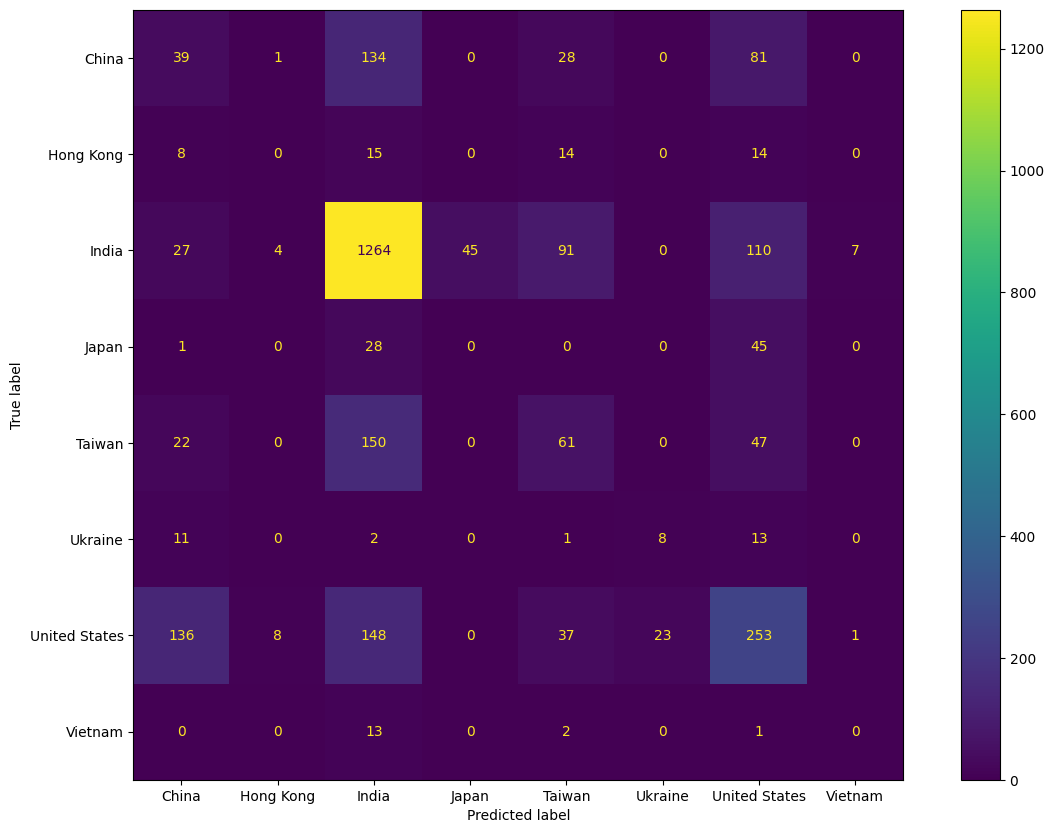

In [44]:
y_pred_test = svc_cv.predict(X_test_combined)

print(classification_report(y_test, y_pred_test))

print("f1_score : ",f1_score(y_test, y_pred_test, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_test), display_labels=svc_cv.classes_)

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()